In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [52]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
print(f"Dataset Shape: {df.shape}")
print("\nClass Distribution:\n", df['label'].value_counts())

encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [53]:
x_train, x_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [54]:
MAX_WORDS = 5000
MAX_LEN = 50
EMBEDDING_DIM = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_LEN)
x_test_pad = pad_sequences(x_test_seq, maxlen=MAX_LEN)

In [55]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
    GRU(units=64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False),
    Dense(units=32, activation='relu'),
    Dropout(0.3),
    Dense(units=1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 64)              │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print("\nStarting Model Training...")
history = model.fit(
    x_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


Starting Model Training...
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - accuracy: 0.8666 - loss: 0.3749 - val_accuracy: 0.9507 - val_loss: 0.1597
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.9816 - loss: 0.0715 - val_accuracy: 0.9798 - val_loss: 0.0660
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.9910 - loss: 0.0299 - val_accuracy: 0.9888 - val_loss: 0.0474
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9963 - loss: 0.0163 - val_accuracy: 0.9865 - val_loss: 0.0498
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.9983 - loss: 0.0074 - val_accuracy: 0.9910 - val_loss: 0.0492
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9888 - val_loss: 0.0497


In [57]:
print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(x_test_pad, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

y_pred_probs = model.predict(x_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Evaluating Model on Test Data...
Test Loss: 0.0575
Test Accuracy: 98.74%
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



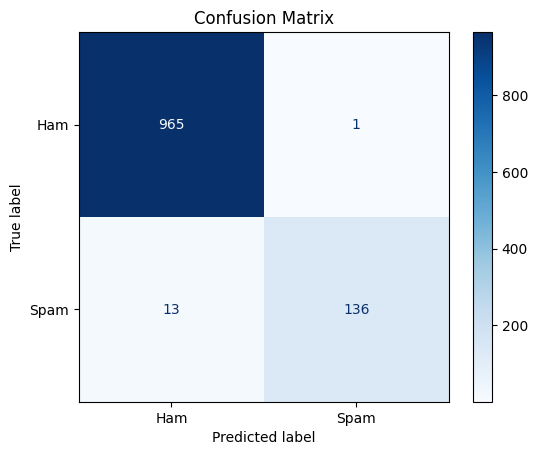

In [66]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [67]:
def predict_multiple_sms(messages_list):
    print("\n--- Batch SMS Prediction ---")
    for msg in messages_list:
        seq = tokenizer.texts_to_sequences([msg])
        padded = pad_sequences(seq, maxlen=MAX_LEN)
        probability = model.predict(padded, verbose=0)[0][0]
        
        if probability > 0.5:
            result = f"SPAM ({probability*100:.1f}%)"
        else:
            result = f"HAM ({probability*100:.1f}%)"
            
        print(f"Message: \"{msg}\" ---> Result: {result}")

In [68]:
test_messages = [
    "CONGRATULATIONS! You won a $1,000 Walmart Gift Card! Click this link to claim it now: http://bit.ly",
    "Hey, are we still meeting for lunch today at 1 PM?",
    "URGENT! Your mobile account has won £2000 cash prize. Call 09066361531 to claim."
]

predict_multiple_sms(test_messages)


--- Batch SMS Prediction ---
Message: "CONGRATULATIONS! You won a $1,000 Walmart Gift Card! Click this link to claim it now: http://bit.ly" ---> Result: SPAM (98.0%)
Message: "Hey, are we still meeting for lunch today at 1 PM?" ---> Result: HAM (0.4%)
Message: "URGENT! Your mobile account has won £2000 cash prize. Call 09066361531 to claim." ---> Result: SPAM (100.0%)


In [70]:
single_test_msg = df['text'].iloc[10]
seq = tokenizer.texts_to_sequences([single_test_msg])
padded = pad_sequences(seq, maxlen=MAX_LEN)
probability = model.predict(padded, verbose=0)[0][0]

if probability > 0.5:
    result = "SPAM"
else:
    result = "HAM"

print(f"Message: \"{single_test_msg}\"")
print(f"Result: {result}")

Message: "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."
Result: HAM


In [73]:
single_test_msg = df['text'].iloc[5] 

seq = tokenizer.texts_to_sequences([single_test_msg])
padded = pad_sequences(seq, maxlen=MAX_LEN)
probability = model.predict(padded, verbose=0)[0][0]

if probability > 0.5:
    result = "SPAM"
else:
    result = "HAM"

print(f"Message: \"{single_test_msg}\"")
print(f"Result: {result}")

Message: "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv"
Result: SPAM
